In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

PARQUET_PATH = "possessions.parquet"   # adjust as needed

df = pd.read_parquet(PARQUET_PATH)
print(f"{df.shape[0]:,} possessions  |  {df.shape[1]} columns")
df.head(25)


5,878,297 possessions  |  45 columns


,game_id,poss_id,playnum,date,period,possession,clock,awayname,away_score,away_event,...,p3,p4,p5,p6,p7,p8,p9,outcome,sec_remaining_game,score_diff
0,201011240MIN,0,0,11/24/2010,1,0.0,12:00.0,SAS,0,Start of 1st quarter,...,3,4,5,6,7,8,9,other,720,0
1,201011240MIN,1,1,11/24/2010,1,0.0,12:00.0,SAS,0,Jump ball: D. Miličić vs. T. Duncan (K. Love g...,...,3,4,5,6,7,8,9,other,720,0
2,201011240MIN,2,2,11/24/2010,1,1.0,11:44.0,SAS,0,None,...,3,4,5,6,7,8,9,made_2pt_FG,704,2
3,201011240MIN,3,3,11/24/2010,1,2.0,11:30.0,SAS,2,R. Jefferson makes 2-pt dunk from 1 ft (assist...,...,3,4,5,6,7,8,9,made_2pt_FG,690,0
4,201011240MIN,4,5,11/24/2010,1,4.0,11:10.0,SAS,2,Defensive rebound by T. Parker,...,3,4,5,6,7,8,9,other,670,0
5,201011240MIN,5,7,11/24/2010,1,4.0,10:53.0,SAS,2,Turnover by T. Duncan (offensive foul),...,3,4,5,6,7,8,9,turnover,653,0
6,201011240MIN,6,8,11/24/2010,1,5.0,10:42.0,SAS,2,None,...,3,4,5,6,7,8,9,made_2pt_FG,642,2
7,201011240MIN,7,9,11/24/2010,1,6.0,10:28.0,SAS,4,R. Jefferson makes 2-pt jump shot from 20 ft (...,...,3,4,5,6,7,8,9,made_2pt_FG,628,0
8,201011240MIN,8,11,11/24/2010,1,7.0,10:19.0,SAS,4,None,...,3,4,5,6,7,8,9,FT,619,1
9,201011240MIN,9,12,11/24/2010,1,7.0,10:19.0,SAS,4,T. Duncan misses 2-pt jump shot from 19 ft,...,3,4,5,6,7,8,9,FT,619,2


,label,n,pct
0,made_2pt_FG,1568472,0.266824
1,FT,1168692,0.198815
2,other,1159118,0.197186
3,turnover,764434,0.130043
4,missed_2pt_FG,543337,0.092431
5,made_3pt_FG,412751,0.070216
6,missed_3pt_FG,261493,0.044484


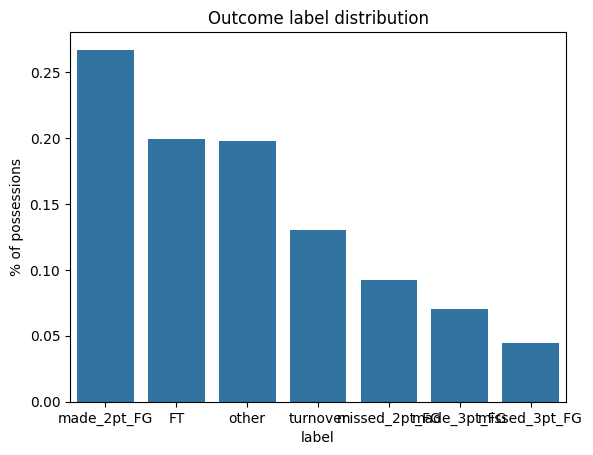

In [3]:
label_counts = (
    df["outcome"]
    .value_counts(dropna=False)
    .rename_axis("label")
    .reset_index(name="n")
    .assign(pct=lambda d: d["n"] / d["n"].sum())
)
display(label_counts)

sns.barplot(data=label_counts, x="label", y="pct")
plt.title("Outcome label distribution"); plt.ylabel("% of possessions"); plt.show()


In [4]:
player_cols = [f"p{i}" for i in range(10)]
missing_mask = (df[player_cols] == -1).any(axis=1)
print(f"Rows with ≥1 missing player ID: {missing_mask.mean():.3%}")


Rows with ≥1 missing player ID: 0.000%


In [5]:
label_to_pts = {"3_pts": 3, "2_pts": 2, "1_pt": 1, "0_pts": 0, "turnover": 0}
df["label_pts"] = df["outcome"].map(label_to_pts)

err = (df["label_pts"] - df["points"]).abs()
print(f"Mean |predicted_pts - actual_pts| = {err.mean():.4f}")


Mean |predicted_pts - actual_pts| = 0.0000


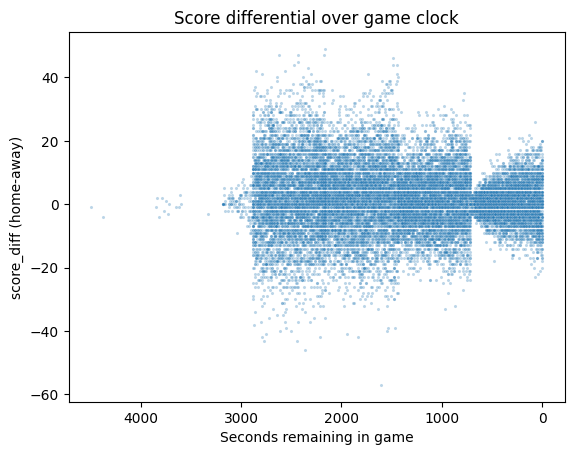

In [6]:
sns.scatterplot(data=df.sample(20000), x="sec_remaining_game", y="score_diff",
                s=5, alpha=0.3)
plt.gca().invert_xaxis()
plt.title("Score differential over game clock");
plt.xlabel("Seconds remaining in game"); plt.ylabel("score_diff (home-away)");


1999 → 2023


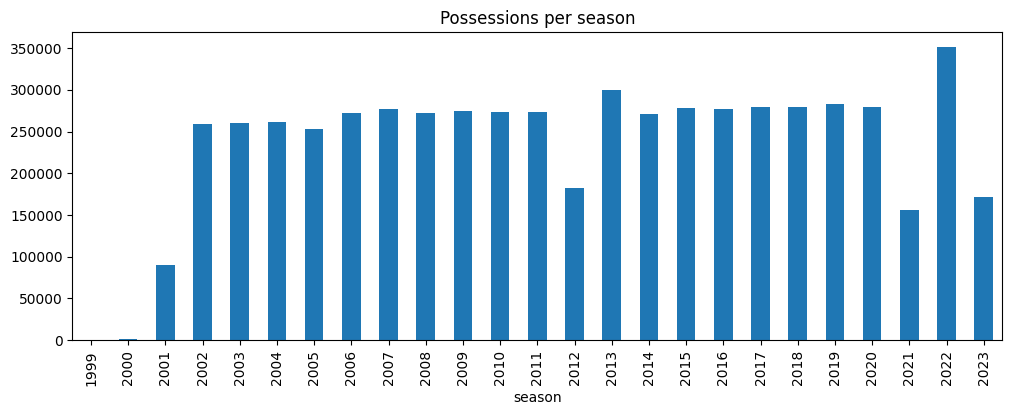

In [7]:
print(df["season"].min(), "→", df["season"].max())

season_counts = df["season"].value_counts().sort_index()
season_counts.plot(kind="bar", figsize=(12,4), title="Possessions per season");


In [8]:
import json, pathlib

lookup_df = pd.read_csv(pathlib.Path(PARQUET_PATH).with_name("player_season_lookup.csv"))
print("player-season IDs:", len(lookup_df))
print("unique players  :", lookup_df["player"].nunique())


player-season IDs: 12821
unique players  : 2310


In [9]:
PARQUET = "possessions.parquet"
LOOKUP  = "player_season_lookup.csv"   # written by the pipeline


In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from functools import lru_cache
sns.set_context("talk")


In [11]:
from functools import lru_cache
import pandas as pd

@lru_cache
def load_pbp(*cols):
    """
    Lazy-load Parquet. Pass column names as separate arguments:
        df = load_pbp("season", "outcome")
    or call with no args to load all columns.
    """
    cols = None if len(cols) == 0 else cols  # tuple already
    return pd.read_parquet(PARQUET, columns=cols)


In [12]:

def player_name_map():
    lu = pd.read_csv(LOOKUP)             # player, season, player_season_id
    return lu.set_index("player_season_id")["player"].to_dict()


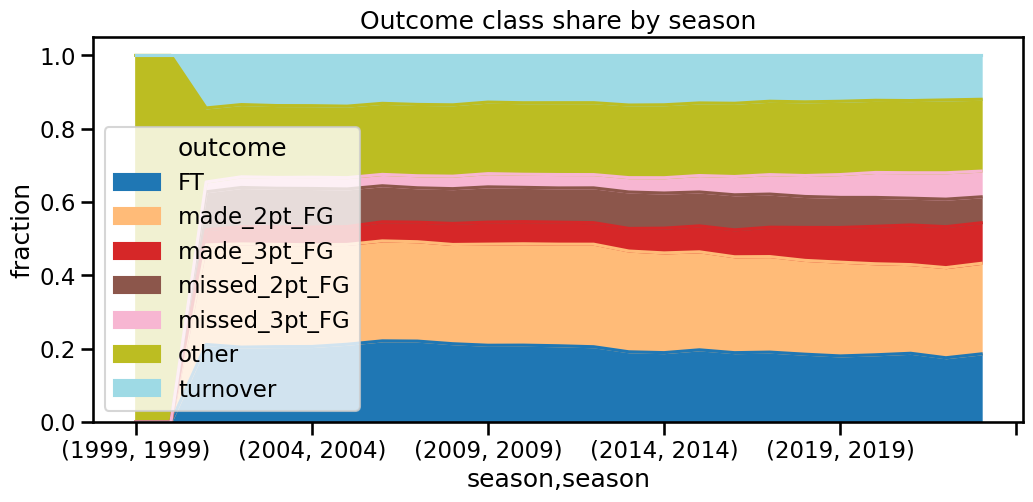

In [13]:
df = load_pbp("season", "outcome")
df_full = load_pbp()                # all columns
share_by_season = (
    df.value_counts(["season", "outcome"])
      .groupby(level=0)
      .apply(lambda s: s / s.sum())
      .unstack(fill_value=0)
      .sort_index()
)
share_by_season.plot.area(figsize=(12,5), colormap="tab20")
plt.title("Outcome class share by season"); plt.ylabel("fraction"); plt.show()


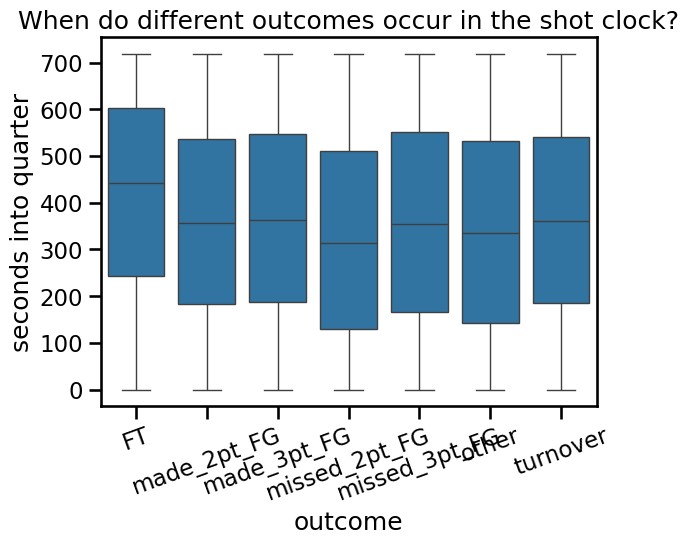

In [14]:
secs = load_pbp("sec_remaining_game", "period", "outcome")
secs["sec_remaining_qtr"] = (secs["period"]*720 - secs["sec_remaining_game"]) % 720
sns.boxplot(data=secs.sample(200_000),
            x="outcome", y="sec_remaining_qtr", order=share_by_season.columns)
plt.xticks(rotation=20); plt.ylabel("seconds into quarter")
plt.title("When do different outcomes occur in the shot clock?");


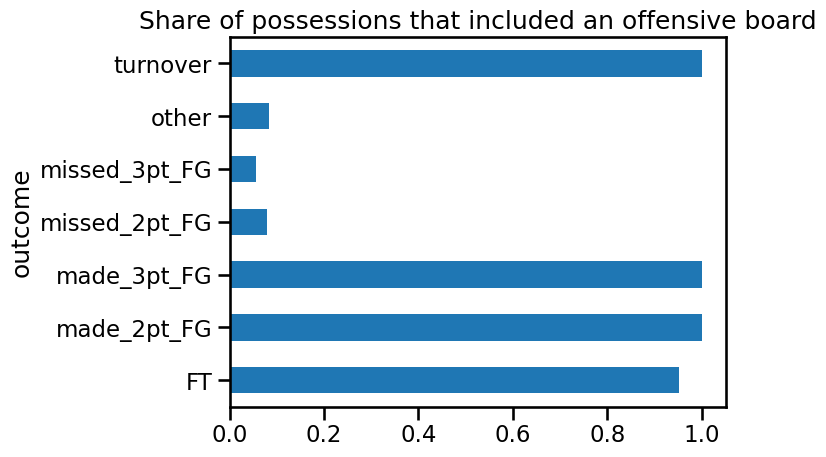

In [15]:
df = load_pbp("event_type", "outcome")
oreb_mask = df["event_type"].eq("rebound_def").groupby(df.index).transform("all").eq(False)
oreb_rate = df.loc[oreb_mask].value_counts("outcome") / df.value_counts("outcome")
oreb_rate.plot.barh()
plt.title("Share of possessions that included an offensive board");


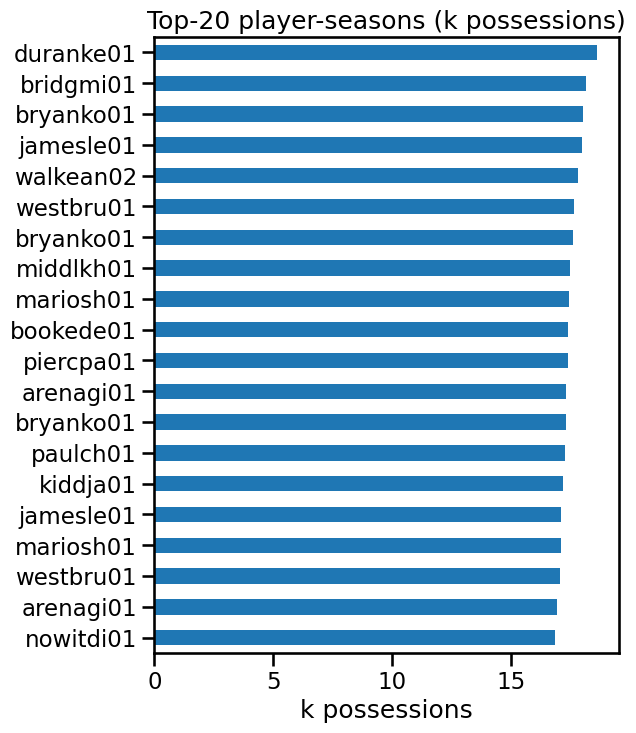

In [16]:
# ---- 4A. possession volume per player-season -------------------------------
ply_cols = [f"p{i}" for i in range(10)]
df = load_pbp(*ply_cols, "season")      # <- separate positional args

vol = (
    df[ply_cols].stack()
      .value_counts()
      .head(20) / 1_000                 # thousands of possessions
)

vol.index = vol.index.map(player_name_map())   # id → name
vol.sort_values().plot.barh(figsize=(6,8))
plt.title("Top-20 player-seasons (k possessions)"); plt.xlabel("k possessions");

In [17]:
# columns holding the 10 player-season IDs
ply_cols = [f"p{i}" for i in range(10)]
df = load_pbp(*ply_cols)

# ------------------------------------------------------------------
#  most-frequent 5-man vs 5-man units across all seasons
# ------------------------------------------------------------------
five = (
    df.groupby(ply_cols)
      .size()                           # count rows (possessions)
      .sort_values(ascending=False)
      .head(10)
)

def fmt(lineup_tuple):
    """Pretty-print the 10-ID tuple as 5 offence vs 5 defence names."""
    names = [player_name_map()[pid] for pid in lineup_tuple]
    return " / ".join(names[:5]) + "  vs  " + " / ".join(names[5:])

pd.DataFrame({
    "lineup": [fmt(tup) for tup in five.index],
    "poss": five.values
})


,lineup,poss
0,chrisdo01 / divacvl01 / bibbymi01 / webbech01 ...,305
1,battish01 / hayesch01 / alstora01 / mingya01 /...,286
2,smithjo03 / johnsjo02 / bibbymi01 / horfoal01 ...,274
3,lillada01 / mccolcj01 / powelno01 / covinro01 ...,250
4,jamesle01 / ilgauzy01 / goodedr01 / murraro01 ...,245
5,martike01 / kiddja01 / kittlke01 / vanhoke01 /...,233
6,varejan01 / jamesle01 / westde01 / ilgauzy01 /...,232
7,allenra02 / rondora01 / perkike01 / garneke01 ...,225
8,allenra02 / davisgl01 / rondora01 / perkike01 ...,221
9,wallara01 / wallabe01 / princta01 / hamilri01 ...,214


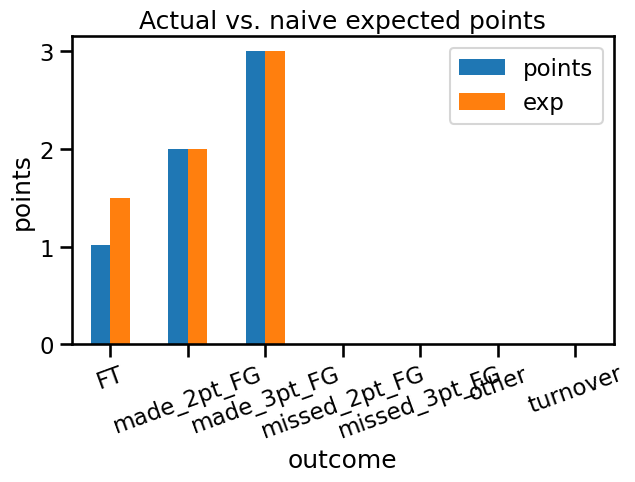

In [18]:
# mapping from label → naive point expectation
label_pts = {
    "made_3pt_FG":        3,
    "made_2pt_FG":        2,
    "missed_3pt_FG":      0,
    "missed_2pt_FG":      0,
    "FT":                 1.5,   # average over all FT sequences
    "turnover":           0,
    "other":              0,
}

df_pts = load_pbp("outcome", "points")
df_pts["exp"] = df_pts["outcome"].map(label_pts)

(df_pts.groupby("outcome")[["points", "exp"]].mean()
      .plot.bar(rot=20, figsize=(7,4)))
plt.ylabel("points"); plt.title("Actual vs. naive expected points");


In [ ]:
from sklearn.manifold import TSNE
import numpy as np

ply_cols = [f"p{i}" for i in range(10)]
df = load_pbp(*ply_cols)

# build co-occurrence matrix for top 2000 player-season tokens
top_ids = df[ply_cols].stack().value_counts().head(2000).index
co_mat  = pd.get_dummies(df[ply_cols].stack()).groupby(level=0).sum()[top_ids]

emb = TSNE(perplexity=40, learning_rate=200, init="random", random_state=42)\
        .fit_transform(co_mat.T.values)

plt.figure(figsize=(7,7))
plt.scatter(emb[:,0], emb[:,1], s=8, alpha=0.6)

# annotate every ~80th point to avoid clutter
for i,(x,y) in enumerate(emb):
    if i % 80 == 0:
        plt.text(x, y, player_name_map()[top_ids[i]][:7], fontsize=7)

plt.title("t-SNE of player-season co-occurrence"); plt.axis('off');
